In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.config import *
from src.io import *
from src.procesamiento import *
from src.visualizacion import *
from src.funciones_complejas import *

# Celda 1: Importaciones y configuración
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import ast
import numpy as np

In [2]:
# CONFIGURACIÓN Y CARGA DE DATOS
############################################################

trayectorias = pd.read_excel(RUTA_EXCEL, sheet_name=2)
df_pacientes = pd.read_excel(RUTA_EXCEL, sheet_name=0) 

# --- NUEVO: AGRUPAR TRAYECTORIAS LARGAS PARA LOS TOPS ---

# Creamos una columna nueva para no romper los gráficos de saltos individuales
trayectorias['ruta_para_top'] = trayectorias['ruta_complejidad_str'].apply(agrupar_trayectorias_largas)


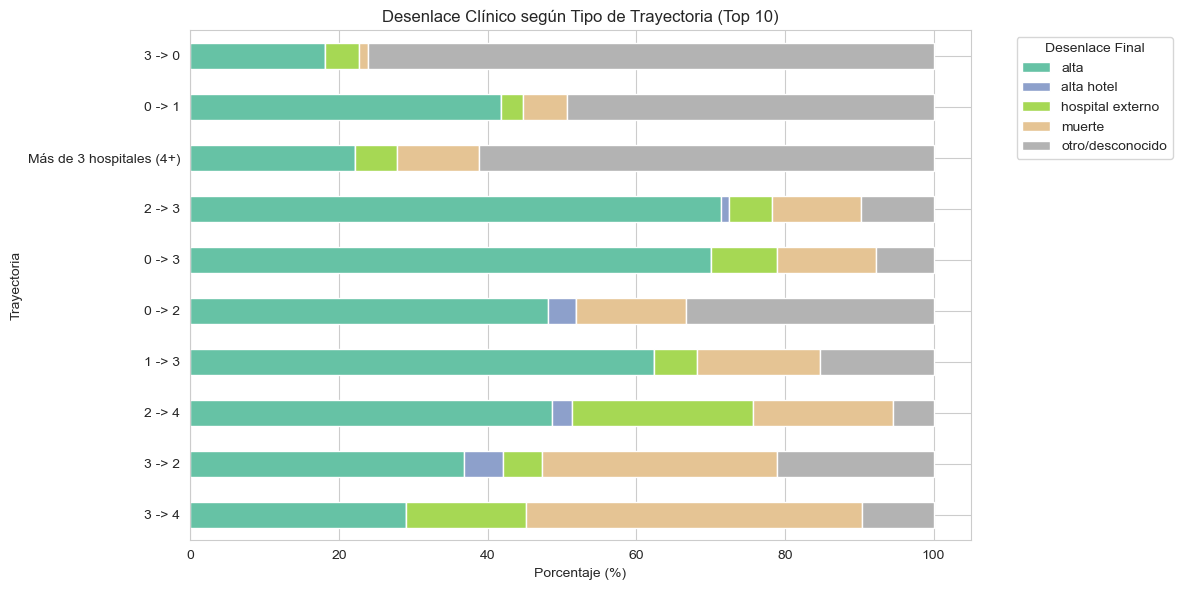

In [3]:
# 1. Desenlaces según el tipo de trayectoria (Alta vs Muerte, etc.)
###################################################################

# Filtramos solo el top 10 o 15 de rutas para que el gráfico sea legible
top_rutas = trayectorias['ruta_para_top'].value_counts().head(10).index
df_top_rutas = trayectorias[trayectorias['ruta_para_top'].isin(top_rutas)]

# Calculamos la proporción de desenlaces por ruta
crosstab_desenlaces = pd.crosstab(
    df_top_rutas['ruta_para_top'], 
    df_top_rutas['motivo_fin_caso'], 
    normalize='index' # Esto lo hace proporcional (del 0 al 1)
) * 100

# Ordenamos por la tasa de mortalidad o alta para darle sentido de lectura
if 'muerte' in crosstab_desenlaces.columns:
    crosstab_desenlaces = crosstab_desenlaces.sort_values('muerte', ascending=False)

# Gráfico
plt.figure(figsize=(12, 6))
crosstab_desenlaces.plot(kind='barh', stacked=True, colormap='Set2', ax=plt.gca())
plt.title('Desenlace Clínico según Tipo de Trayectoria (Top 10)')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Trayectoria')
plt.legend(title='Desenlace Final', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
# 2. Tiempos por Nodo (Ej: ¿Cuánto en 0 y cuánto en 3?)
#######################################################

# 1. Cargar episodios y calcular los días de estadía por cada eslabón
episodios = pd.read_excel(RUTA_EXCEL, sheet_name=1)
episodios['fecha_ingreso'] = pd.to_datetime(episodios['fecha_ingreso'])
episodios['fecha_egreso'] = pd.to_datetime(episodios['fecha_egreso'])
episodios['dias_en_nodo'] = (episodios['fecha_egreso'] - episodios['fecha_ingreso']).dt.days

# 2. Cargar el CSV y hacer una limpieza fuerte de los textos antes de cruzar
df_hospitales = pd.read_csv('../data/hospitales_coordenadas.csv', encoding='utf-8')

# LIMPIEZA CLAVE: Pasamos todo a mayúsculas y sacamos espacios en blanco extra
episodios['hospital_ingreso'] = episodios['hospital_ingreso'].astype(str).str.upper().str.strip()
df_hospitales['Nombre Hospital'] = df_hospitales['Nombre Hospital'].astype(str).str.upper().str.strip()

# Hacemos el cruce
episodios = episodios.merge(
    df_hospitales[['Nombre Hospital', 'complejidad']], 
    left_on='hospital_ingreso',  
    right_on='Nombre Hospital', 
    how='left'
)

episodios['nivel_complejidad'] = episodios['complejidad'].fillna('Desc').astype(str).str.replace('.0', '', regex=False)

# ==========================================
# 🛑 DETECTOR DE HOSPITALES HUÉRFANOS 🛑
# Si te sigue faltando el nivel 3, corré esto para ver qué hospitales no se cruzaron:
hosp_sin_match = episodios[episodios['nivel_complejidad'] == 'Desc']['hospital_ingreso'].unique()
print(f"Hay {len(hosp_sin_match)} hospitales en episodios que NO están en tu CSV de coordenadas:")
# Descomentá la siguiente línea si querés ver la lista negra de los que no cruzaron
# print(hosp_sin_match)
# ==========================================
# 3. Identificar pacientes que hicieron una ruta específica (Ej: "0 -> 3")
pacientes_0_3 = trayectorias[trayectorias['ruta_complejidad_str'] == '0 -> 3']['paciente_id']

# 4. Traer SOLO los episodios de esos pacientes específicos
episodios_0_3 = episodios[episodios['paciente_id'].isin(pacientes_0_3)]

# 5. Agrupar y ver las métricas de tiempo en cada nivel
tiempos_por_nodo = episodios_0_3.groupby('nivel_complejidad')['dias_en_nodo'].agg(
    Mediana='median', 
    Promedio='mean', 
    Episodios_Totales='count'
).round(1)

print("Tiempos de internación (en días) para pacientes con ruta '0 -> 3':")
display(tiempos_por_nodo)

# (Podés encapsular esto en una función rápida si querés repetirlo para '3 -> 0' o '0 -> 1')

Hay 0 hospitales en episodios que NO están en tu CSV de coordenadas:
Tiempos de internación (en días) para pacientes con ruta '0 -> 3':


,Mediana,Promedio,Episodios_Totales
nivel_complejidad,,,
0,2.0,2.3,779


In [ ]:
# 3. Agrupación por "Origen de la Trayectoria" en el tiempo
# =========================================================

# Creamos una columna para saber dónde empezó (el primer elemento del string)
# Si tu ruta es "0 -> 3", se queda con "0"
trayectorias['nodo_origen'] = trayectorias['ruta_complejidad_str'].apply(lambda x: str(x).split('->')[0].strip() if pd.notna(x) else 'Desconocido')

# Filtramos solo los que empiezan en UPA (ejemplo: '0')
df_origen_0 = trayectorias[trayectorias['nodo_origen'] == '0']

# Agrupamos por OLA y vemos cómo terminaron o cuántos traslados tuvieron
evolucion_upa = pd.crosstab(df_origen_0['Periodo_Covid'], df_origen_0['motivo_fin_caso'], normalize='index') * 100

# Reordenamos según tus periodos
nombres_periodos = [p[0] for p in PERIODOS]
evolucion_upa = evolucion_upa.reindex([p for p in nombres_periodos if p in evolucion_upa.index])

plt.figure(figsize=(10, 5))
evolucion_upa.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Evolución de Desenlaces para pacientes que iniciaron en Nivel 0 (UPA)')
plt.ylabel('Porcentaje de pacientes (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

KeyError: 'Periodo'

In [8]:
# 4. EL GRÁFICO ESTRELLA: Boxplot Doble (Tiempo al primer traslado vs Tiempo total)
#===================================================================================

# 1. ARMADO DEL CAMPO TIEMPO (Si no lo tenés, hay que calcularlo)
# Supongamos que ya cruzaste las fechas inicial y final. 
# Si no, las calculas restando fechas del df_pacientes original.
trayectorias['tiempo_hasta_traslado'] = (pd.to_datetime(trayectorias['fecha_primer_traslado']) - pd.to_datetime(trayectorias['fecha_ingreso_trayectoria'])).dt.days
trayectorias['tiempo_total_sistema'] = trayectorias['dias_estadia_total'] # O (fecha_egreso_final - fecha_ingreso_trayectoria)

# 2. Filtrar solo las trayectorias de exactamente 2 pasos (ej: 0->3, 0->1, 3->0)
trayectorias['cantidad_nodos'] = trayectorias['ruta_complejidad_str'].apply(lambda x: len(str(x).split('->')) if pd.notna(x) else 0)
df_2_pasos = trayectorias[trayectorias['cantidad_nodos'] == 2].copy()

# Filtramos las más importantes para no saturar el gráfico
top_rutas_2_pasos = df_2_pasos['ruta_complejidad_str'].value_counts().head(5).index
df_2_pasos_top = df_2_pasos[df_2_pasos['ruta_complejidad_str'].isin(top_rutas_2_pasos)]

# 3. MAGIA DE PANDAS: Usamos 'melt' para poner ambos tiempos en una misma columna
# Esto permite que Seaborn los grafique como dos cajas de distinto color una al lado de la otra
df_melted = pd.melt(
    df_2_pasos_top, 
    id_vars=['ruta_complejidad_str'], 
    value_vars=['tiempo_hasta_traslado', 'tiempo_total_sistema'],
    var_name='Tipo de Métrica', 
    value_name='Días'
)

# Renombramos para que el gráfico quede lindo
df_melted['Tipo de Métrica'] = df_melted['Tipo de Métrica'].replace({
    'tiempo_hasta_traslado': 'Días hasta el traslado',
    'tiempo_total_sistema': 'Días totales en el sistema'
})

# 4. EL BOXPLOT DIRECTO
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_melted, 
    y='ruta_complejidad_str', 
    x='Días', 
    hue='Tipo de Métrica',
    palette=['#4C72B0', '#DD8452'], # Colores piolas y serios
    showfliers=False # Oculta los outliers extremos para que la "caja" se vea bien
)

plt.title('Tiempos de Internación: Hasta el traslado vs. Total del sistema\n(Trayectorias de 2 niveles más frecuentes)', fontsize=14, pad=15)
plt.xlabel('Cantidad de Días', fontsize=12)
plt.ylabel('Trayectoria (Origen → Destino)', fontsize=12)
plt.legend(title='', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

KeyError: 'fecha_primer_traslado'